# Rubin/LSST — Stable Stars in Deep Drilling Fields (Simbad query)

Retrieve stellar objects from the **Simbad** astronomical database for each
Rubin/LSST Deep Drilling Field (DDF).  
The goal is to build a catalogue of photometrically **stable** (non-variable) stars
in a configurable V-band magnitude range that can subsequently be cross-matched
directly against Rubin Butler/Gen3 data (not Fink) for calibration and
systematic-effect studies.


- author : Sylvie Dagoret-Campagne
- affiliation : IJCLab/IN2P3/CNRS, Université Paris-Saclay
- creation : 2026-06-18
- last update : 2026-06-18 (fix is_not_variable: test numpy.ma mask before string comparison)
- last update : 2026-06-23 : Select only mag 20 or below

## 1. Imports & configuration

In [1]:
import os
import time
import warnings

import numpy as np
import numpy.ma as ma
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astroquery.simbad import Simbad

warnings.filterwarnings("ignore")

print(f"numpy    version : {np.__version__}")
print(f"pandas   version : {pd.__version__}")

numpy    version : 1.26.4
pandas   version : 2.2.3


In [2]:
# Select matplotlib backend: interactive if ipympl is available, otherwise inline
try:
    import ipympl  # noqa: F401

    %matplotlib widget
    print("ipympl found → interactive backend")
except ImportError:
    %matplotlib inline
    print("ipympl NOT found → inline")

ipympl found → interactive backend


In [3]:
# ── Deep Drilling Fields (DDFs) ───────────────────────────────────────────────
# Keys: field name / Values: (RA_deg, Dec_deg) J2000 ICRS
DEEP_FIELDS = {
    "COSMOS": (150.1191, 2.2058),
    "ELAIS-S1": (9.4500, -44.000),
    "XMM-LSS": (35.7080, -4.750),
    "ECDFS": (53.1250, -27.800),
    #"EDFS-a": (58.9000, -49.315),
    #"EDFS-b": (63.6000, -47.600),
    #"EDFS": (61.2400, -48.423),
    #"M49": (187.4000, 8.000),
}

# ── Search radius (degrees) ───────────────────────────────────────────────────
# 0.5 deg ≈ the DDF half-width; increase to 1.0 deg to cover the full DDF footprint
SEARCH_RADIUS_DEG = 1.5  # [adjustable]

# ── Magnitude selection window (V band) ──────────────────────────────────────
# Rubin r-band saturation limit is ~ 16 mag; faint limit depends on purpose.
MAG_MIN = 17.0  # [adjustable]
MAG_MAX = 20.0  # [adjustable]

# ── Object-type filtering ─────────────────────────────────────────────────────
# Simbad otype values that start with '*' are stellar objects.
# Set to False to keep all otypes and filter manually afterwards.
FILTER_STARS_ONLY = True  # [adjustable]

# ── Stability filter ──────────────────────────────────────────────────────────
# When True, only stars with NO variability record in Simbad are retained.
KEEP_STABLE_ONLY = True  # [adjustable]

# ── Force re-query even if a CSV cache exists ─────────────────────────────────
FORCE_RELOAD = False  # [adjustable]

# ── Output directories ────────────────────────────────────────────────────────
NB_TAG = "SIMBAD_01"
DIR_DATA = f"data_{NB_TAG}"
DIR_FIGS = f"figs_{NB_TAG}"
os.makedirs(DIR_DATA, exist_ok=True)
os.makedirs(DIR_FIGS, exist_ok=True)
print(f"Data : {os.path.abspath(DIR_DATA)}")
print(f"Figs : {os.path.abspath(DIR_FIGS)}")

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
    }
)


def savefig(name: str) -> None:
    """Save the current figure to PDF and PNG inside DIR_FIGS."""
    for ext in ("pdf", "png"):
        plt.savefig(os.path.join(DIR_FIGS, f"{name}.{ext}"), bbox_inches="tight")
    print(f"  -> saved {name}.{{pdf,png}}")


print("Configuration done.")

Data : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/data_SIMBAD_01
Figs : /Users/dagoret/Desktop/RubinLSSTSkyAlerts/notebooks/10_askSimbad/figs_SIMBAD_01
Configuration done.


## 2. Simbad field configuration

We request the following Simbad VOTable fields in addition to the default
coordinates and identifier:

| Field        | Description                                          |
|--------------|------------------------------------------------------|
| `V`          | V-band magnitude (Johnson)                           |
| `B`          | B-band magnitude                                     |
| `R`          | R-band magnitude                                     |
| `sp_type`    | Spectral type                                        |
| `mesvar`     | Variability measurements table                       |
| `plx_value`  | Parallax (mas) — Hipparcos/Gaia when available       |
| `pmra`       | Proper motion in RA × cos(Dec) (mas/yr)              |
| `pmdec`      | Proper motion in Dec (mas/yr)                        |
| `otype`      | Object type — used to select stellar objects         |


In [4]:
# Reset Simbad to its default field set to avoid conflicts between calls
Simbad.reset_votable_fields()

# Request additional columns from Simbad.
# Note: proper motion components must be added individually as 'pmra' and 'pmdec';
#       the combined 'pm' field is not accepted by astroquery.
Simbad.add_votable_fields("V")  # V-band magnitude
Simbad.add_votable_fields("B")  # B-band magnitude
Simbad.add_votable_fields("R")  # R-band magnitude
Simbad.add_votable_fields("I")  # I-band magnitude
# Simbad.add_votable_fields("Z")          # Z-band magnitude
Simbad.add_votable_fields("sp_type")  # spectral type
Simbad.add_votable_fields("mesvar")  # variability table
Simbad.add_votable_fields("plx_value")  # parallax (mas)
Simbad.add_votable_fields("pmra")  # proper motion in RA * cos(Dec) (mas/yr)
Simbad.add_votable_fields("pmdec")  # proper motion in Dec (mas/yr)
Simbad.add_votable_fields("otype")  # object type

print("Simbad VOTable fields configured.")
print("Fields:", Simbad.get_votable_fields())

Simbad VOTable fields configured.
Fields: ['basic.main_id', 'basic.ra', 'basic.dec', 'basic.coo_err_maj', 'basic.coo_err_min', 'basic.coo_err_angle', 'basic.coo_wavelength', 'basic.coo_bibcode', 'allfluxes.V', 'allfluxes.B', 'allfluxes.R', 'allfluxes.I', 'basic.sp_type', 'mesvar.bibcode', 'mesvar.epoch', 'mesvar.epoch_prec', 'mesvar.lowvmax', 'mesvar.magtyp', 'mesvar.mespos', 'mesvar.period', 'mesvar.period_prec', 'mesvar.raisingtime', 'mesvar.raisingtime_prec', 'mesvar.r_epoch', 'mesvar.r_period', 'mesvar.r_raisingtime', 'mesvar.r_vmax', 'mesvar.r_vmin', 'mesvar.upperiod', 'mesvar.uppvmin', 'mesvar.vartyp', 'mesvar.vmax', 'mesvar.vmax_prec', 'mesvar.vmin', 'mesvar.vmin_prec', 'basic.plx_value', 'basic.pmra', 'basic.pmdec', 'basic.otype']


## 3. Helper functions

### Note on `mesvar.vartyp` and the masked-array pitfall

Simbad returns `mesvar.vartyp` as an astropy **MaskedColumn**.  
For objects with **no** variability record, the entry is a **masked scalar** —
not the literal string `'--'`.  
The `'--'` you see when printing the table is only astropy's display fill for
masked values; comparing with `!= '--'` (or `!= b'--'`) returns `True` even
for masked entries, which incorrectly flags all stars as variable.

The correct approach is to **test `numpy.ma.is_masked()` first**, and only
fall back to a string comparison for the rare case where an actual string value
is present but empty.


In [5]:
def decode_col(val) -> str:
    """Decode bytes to str, pass str through unchanged."""
    if isinstance(val, bytes):
        return val.decode("utf-8")
    return str(val)


def is_stellar_otype(otype_val) -> bool:
    """
    Return True when the Simbad otype indicates a stellar object.
    In Simbad, stellar otypes start with '*'.  Examples:
      '*'   → generic star
      '**'  → double/multiple star
      'BS*' → blue straggler
      'WD*' → white dwarf
      'Em*' → emission-line star
    Non-stellar otypes: 'G', 'QSO', 'AGN', '?', …
    """
    return decode_col(otype_val).startswith("*")


def extract_vmag(table: Table) -> np.ndarray:
    """
    Return a float array of V-band magnitudes from the Simbad result table.
    Masked or invalid entries become NaN.
    """
    col = table["V"]
    if hasattr(col, "filled"):
        vals = col.filled(fill_value=np.nan)
    else:
        vals = np.array(col)
    return pd.to_numeric(vals, errors="coerce")


def is_not_variable_old(row, vartyp_col: str = "mesvar.vartyp") -> bool:
    """
    Return True when a row has NO variability classification in Simbad,
    i.e. when the star should be considered photometrically stable.

    Background
    ----------
    Simbad returns mesvar.vartyp as an astropy MaskedColumn.  For objects
    with no variability record the cell is a *masked scalar*, not the
    literal string '--'.  The '--' printed by astropy is only its display
    fill value.  Comparing with != '--' returns True even for masked
    entries, which incorrectly flags every star as variable (the bug in
    the cosmosStars.ipynb prototype).

    We therefore test numpy.ma.is_masked() *first*; a masked entry means
    no variability data → stable.  Only if the value is not masked do we
    fall back to a string check for an explicit empty marker.
    """
    col_val = row[vartyp_col]

    # Case 1: numpy masked scalar → no variability record → stable
    if ma.is_masked(col_val):
        return True

    # Case 2: unmasked value present → decode and check for explicit empty markers
    val = decode_col(col_val).strip()
    return val in ("", "--", "nan", "None")


def is_not_variable(row, vartyp_col: str = "mesvar.vartyp") -> bool:
    """
    Return True when a row has NO variability record in Simbad.
    We check both the astropy mask (MaskedColumn) and the string value,
    because Simbad returns masked entries (not the literal '--') for
    objects without any variability measurement.
    """
    col_val = row[vartyp_col]
    # Case 1: astropy masked value → no variability data → stable
    if hasattr(col_val, "mask") and col_val.mask:
        return True
    # Case 2: numpy masked scalar
    try:
        import numpy.ma as ma

        if ma.is_masked(col_val):
            return True
    except Exception:
        pass
    # Case 3: string representation of missing value
    val = decode_col(col_val)
    return val in ("--", "nan", "", "None")


def simbad_query_ddf(
    ra_deg: float,
    dec_deg: float,
    radius_deg: float = SEARCH_RADIUS_DEG,
) -> Table | None:
    """
    Run a Simbad cone search centred on (ra_deg, dec_deg) with the given
    search radius.  Returns the raw Simbad Table or None if no objects found.
    """
    center = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    try:
        result = Simbad.query_region(center, radius=radius_deg * u.deg)
    except Exception as exc:
        print(f"  Simbad query error: {exc}")
        return None
    return result  # None when no objects are found


print("Helper functions defined.")

Helper functions defined.


## 4. Query Simbad for each DDF and cache results

For each DDF the pipeline:
1. Checks whether a CSV cache file already exists (skips the API call if it does
   and `FORCE_RELOAD = False`).
2. Queries Simbad within `SEARCH_RADIUS_DEG` of the field centre.
3. Optionally filters for stellar otypes only (`FILTER_STARS_ONLY`).
4. Filters on the V-band magnitude window `[MAG_MIN, MAG_MAX]`.
5. Tags each row with a `stable` flag based on the Simbad variability table
   (`mesvar.vartyp`), and optionally drops variable stars (`KEEP_STABLE_ONLY`).
6. Saves the filtered table as a CSV file in `DIR_DATA`.


In [6]:
# Dictionary: field_name → filtered pandas DataFrame
ddf_stars: dict[str, pd.DataFrame] = {}

for field_name, (ra, dec) in DEEP_FIELDS.items():
    tag = f"V{MAG_MIN:.0f}-{MAG_MAX:.0f}"
    csv_path = os.path.join(
        DIR_DATA,
        f"{field_name}_stars_{tag}_r{SEARCH_RADIUS_DEG:.1f}deg.csv",
    )

    # ── Load from cache if available ─────────────────────────────────────────
    if os.path.exists(csv_path) and not FORCE_RELOAD:
        df = pd.read_csv(csv_path)
        print(f"[{field_name:12s}] Loaded from cache: {len(df):5d} stars")
        ddf_stars[field_name] = df
        continue

    # ── Query Simbad ─────────────────────────────────────────────────────────
    print(
        f"[{field_name:12s}] Querying Simbad (ra={ra:.4f}, dec={dec:.4f}, r={SEARCH_RADIUS_DEG}°)…",
        end=" ",
        flush=True,
    )
    t0 = time.time()
    result = simbad_query_ddf(ra, dec, radius_deg=SEARCH_RADIUS_DEG)
    elapsed = time.time() - t0

    if result is None or len(result) == 0:
        print(f"→ NO RESULT ({elapsed:.1f}s)")
        ddf_stars[field_name] = pd.DataFrame()
        continue

    print(f"→ {len(result):6d} objects  ({elapsed:.1f}s)")
    table = Table(result)

    # ── Step 1: filter for stellar otypes ────────────────────────────────────
    if FILTER_STARS_ONLY and "otype" in table.colnames:
        star_mask = np.array([is_stellar_otype(v) for v in table["otype"]])
        table = table[star_mask]
        print(f"  After stellar otype filter : {len(table):6d} stars")

    if len(table) == 0:
        print("  No stars after otype filter — skipping field.")
        ddf_stars[field_name] = pd.DataFrame()
        continue

    # ── Step 2: extract V-band magnitude, filter on [MAG_MIN, MAG_MAX] ───────
    if "V" not in table.colnames:
        print("  No V column in result — skipping field.")
        ddf_stars[field_name] = pd.DataFrame()
        continue

    v_vals = extract_vmag(table)
    valid_v_mask = np.isfinite(v_vals)
    table = table[valid_v_mask]
    v_vals = v_vals[valid_v_mask]

    mag_mask = (v_vals >= MAG_MIN) & (v_vals <= MAG_MAX)
    table = table[mag_mask]
    v_vals = v_vals[mag_mask]
    print(f"  After V-mag filter [{MAG_MIN},{MAG_MAX}]  : {len(table):6d} stars")

    if len(table) == 0:
        print("  No stars after magnitude filter — skipping field.")
        ddf_stars[field_name] = pd.DataFrame()
        continue

    # ── Step 3: stability flag from mesvar.vartyp ─────────────────────────────
    # is_not_variable() tests numpy.ma.is_masked() first so that masked entries
    # (= no Simbad variability record) are correctly classified as stable.
    stable_flags = np.ones(len(table), dtype=bool)  # default: stable
    if "mesvar.vartyp" in table.colnames:
        stable_flags = np.array([is_not_variable(row, "mesvar.vartyp") for row in table])
        n_var = int((~stable_flags).sum())
        n_stab = int(stable_flags.sum())
        print(f"  Variability check: {n_stab:5d} stable, {n_var:5d} variable")

    if KEEP_STABLE_ONLY:
        table = table[stable_flags]
        stable_flags = stable_flags[stable_flags]  # all True after filtering
        print(f"  After stability filter       : {len(table):6d} stars")

    if len(table) == 0:
        print("  No stable stars remaining — skipping field.")
        ddf_stars[field_name] = pd.DataFrame()
        continue

    # ── Step 4: build a clean pandas DataFrame ────────────────────────────────
    df = table.to_pandas()

    # Rename columns for clarity
    rename_map = {
        "main_id": "simbad_id",
        "ra": "ra_deg",
        "dec": "dec_deg",
        "V": "V_mag",
        "B": "B_mag",
        "R": "R_mag",
        "I": "I_mag",
        "sp_type": "spectral_type",
        "plx_value": "parallax_mas",
        "pmra": "pmra_mas_yr",
        "pmdec": "pmdec_mas_yr",
        "otype": "simbad_otype",
    }
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

    # Decode bytes columns to str
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)

    # Force numeric types
    for col in ["V_mag", "B_mag", "R_mag", "I_mag", "parallax_mas", "pmra_mas_yr", "pmdec_mas_yr"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Add field identifier and stability flag
    df["field"] = field_name
    df["stable"] = stable_flags if not KEEP_STABLE_ONLY else True

    # ── Step 5: save to CSV ───────────────────────────────────────────────────
    df.to_csv(csv_path, index=False)
    print(f"  → saved {len(df)} rows to {csv_path}")
    ddf_stars[field_name] = df


print("\nQuery loop complete.")

[COSMOS      ] Loaded from cache:  1080 stars
[ELAIS-S1    ] Loaded from cache:     5 stars
[XMM-LSS     ] Loaded from cache:    54 stars
[ECDFS       ] Loaded from cache:   208 stars

Query loop complete.


## 5. Summary table per DDF

In [7]:
rows = []
for field_name, df in ddf_stars.items():
    if df.empty:
        rows.append(
            {
                "field": field_name,
                "n_stars": 0,
                "n_stable": 0,
                "V_mean": np.nan,
                "V_std": np.nan,
                "n_with_parallax": 0,
                "n_with_sptype": 0,
            }
        )
        continue

    n_total = len(df)
    n_stable = int(df["stable"].sum()) if "stable" in df.columns else n_total

    v_col = "V_mag" if "V_mag" in df.columns else None
    v_mean = df[v_col].mean() if v_col else np.nan
    v_std = df[v_col].std() if v_col else np.nan

    n_plx = int(df["parallax_mas"].notna().sum()) if "parallax_mas" in df.columns else 0
    n_spt = (
        int((df["spectral_type"].notna() & (df["spectral_type"] != "") & (df["spectral_type"] != "--")).sum())
        if "spectral_type" in df.columns
        else 0
    )

    rows.append(
        {
            "field": field_name,
            "n_stars": n_total,
            "n_stable": n_stable,
            "V_mean": v_mean,
            "V_std": v_std,
            "n_with_parallax": n_plx,
            "n_with_sptype": n_spt,
        }
    )

df_summary = pd.DataFrame(rows).set_index("field")
print(f"\nSimbad star counts per DDF (V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°):")
print(df_summary.to_string(float_format="{:.2f}".format))


Simbad star counts per DDF (V ∈ [17.0, 20.0], r=1.5°):
          n_stars  n_stable  V_mean  V_std  n_with_parallax  n_with_sptype
field                                                                     
COSMOS       1080      1080   19.21   0.50              993             15
ELAIS-S1        5         5   18.78   1.15                1              0
XMM-LSS        54        54   19.21   0.60               40              1
ECDFS         208       208   18.75   0.83              188              2


## 6. Sky distribution of selected stars per DDF

For each DDF we show the on-sky distribution (RA, Dec) of the selected
stable stars coloured by V-band magnitude.  
The field centre is marked with a red cross.


In [8]:
def plot_star_skymap(df: pd.DataFrame, field_name: str, ra_center: float, dec_center: float) -> None:
    """
    Scatter plot of stable stars in RA/Dec space, coloured by V magnitude.
    The DDF centre is shown as a red cross.
    """
    if df.empty:
        print(f"[{field_name}] No stars — skipping sky map.")
        return
    if "ra_deg" not in df.columns or "dec_deg" not in df.columns:
        print(f"[{field_name}] Missing coordinate columns — skipping.")
        return

    fig, ax = plt.subplots(figsize=(6, 5))

    v_col = "V_mag" if "V_mag" in df.columns else None
    if v_col:
        sc = ax.scatter(
            df["ra_deg"],
            df["dec_deg"],
            c=df[v_col],
            cmap="viridis_r",
            s=20,
            alpha=0.7,
            linewidths=0.3,
            edgecolors="k",
            label=f"stable stars (n={len(df):,})",
        )
        cbar = plt.colorbar(sc, ax=ax, label="V mag")
        cbar.ax.invert_yaxis()
    else:
        ax.scatter(
            df["ra_deg"],
            df["dec_deg"],
            s=20,
            alpha=0.7,
            color="steelblue",
            label=f"stable stars (n={len(df):,})",
        )

    ax.plot(ra_center, dec_center, "r+", ms=14, mew=2.5, label="DDF centre")
    ax.invert_xaxis()  # astronomical convention: RA increases to the left
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(
        f"{field_name} — stable stars from Simbad\nV ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°"
    )
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    savefig(f"skymap_stars_{field_name.replace('-', '_')}")
    plt.show()


print("plot_star_skymap() defined.")

plot_star_skymap() defined.


  -> saved skymap_stars_COSMOS.{pdf,png}


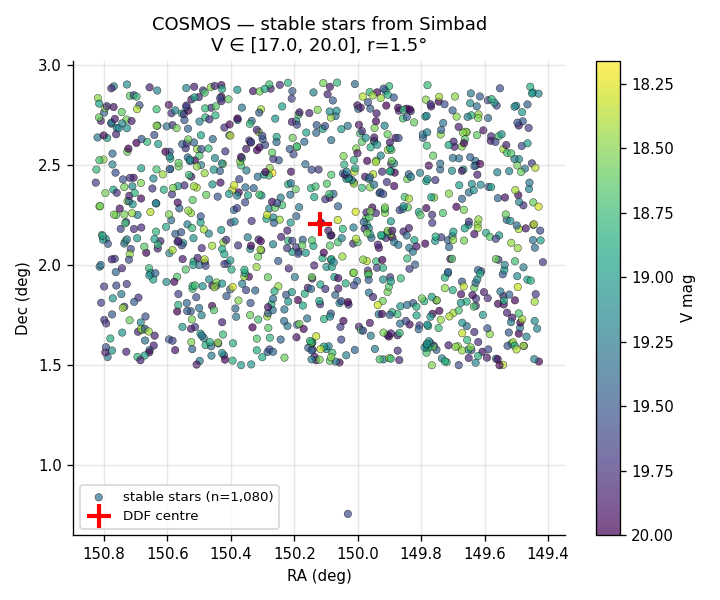

  -> saved skymap_stars_ELAIS_S1.{pdf,png}


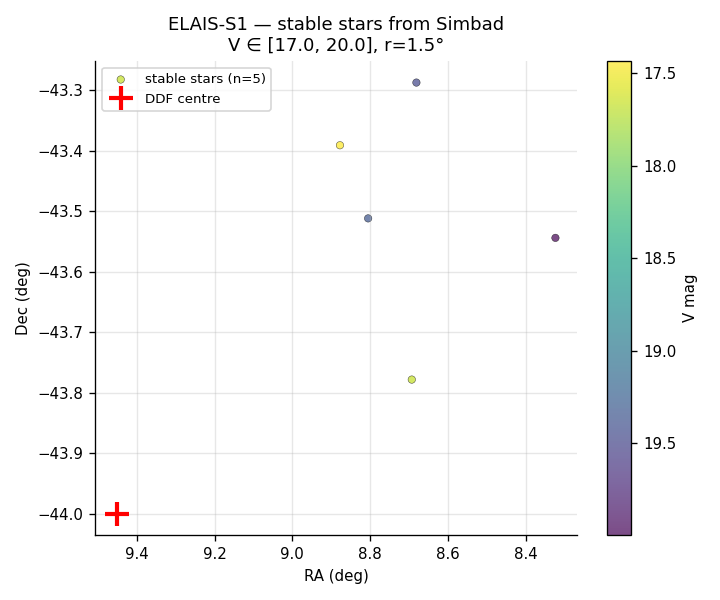

  -> saved skymap_stars_XMM_LSS.{pdf,png}


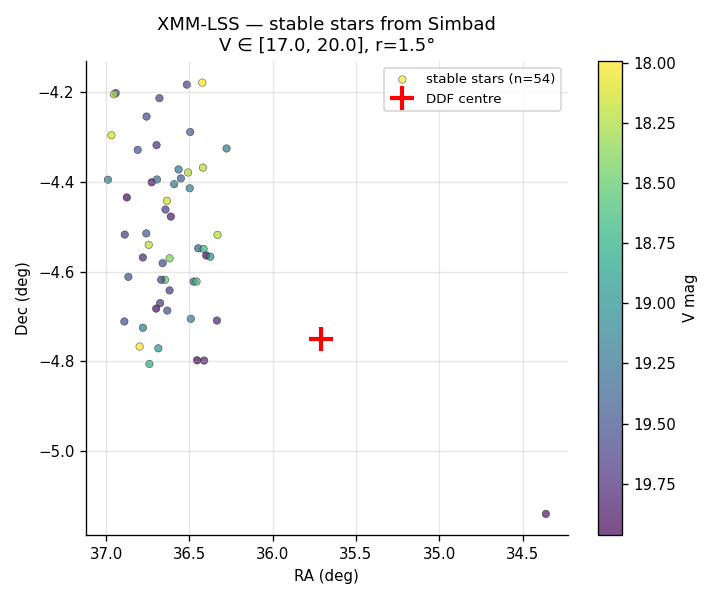

  -> saved skymap_stars_ECDFS.{pdf,png}


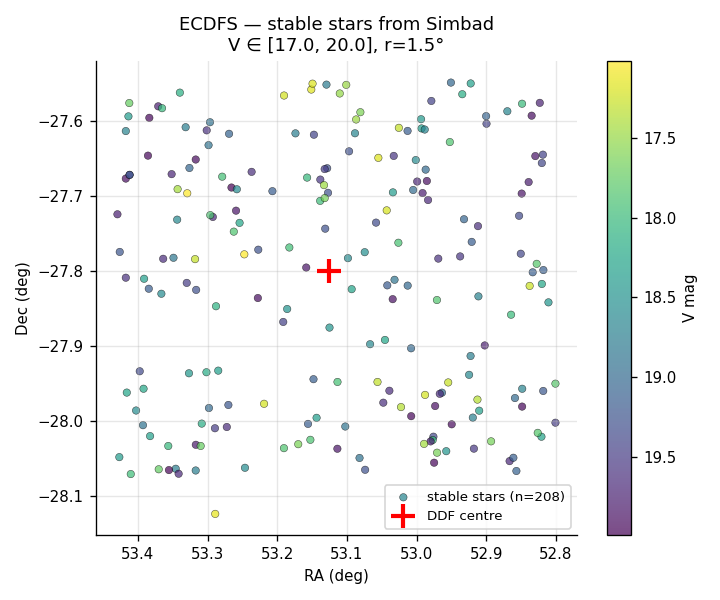

In [9]:
for field_name, df in ddf_stars.items():
    ra_c, dec_c = DEEP_FIELDS[field_name]
    plot_star_skymap(df, field_name, ra_c, dec_c)

## 7. V-magnitude distribution per DDF

Histograms of the V-band magnitude for the selected stable stars in each DDF.
A summary panel (all DDFs overlaid) is shown at the end.


  -> saved vmag_distribution_per_ddf.{pdf,png}


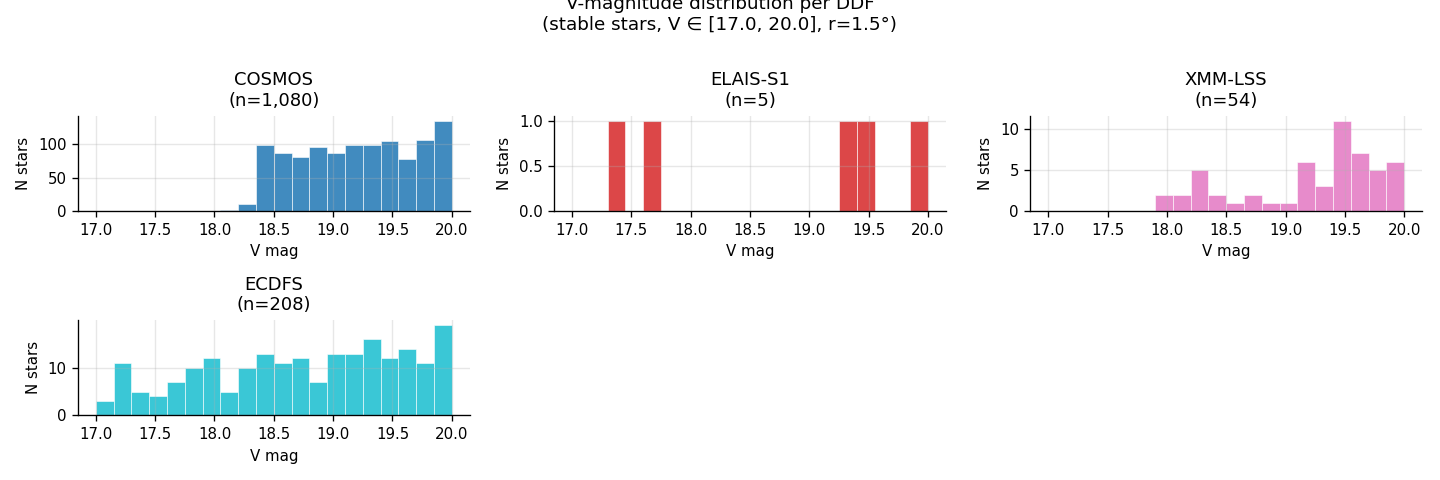

  -> saved vmag_distribution_all_ddfs.{pdf,png}


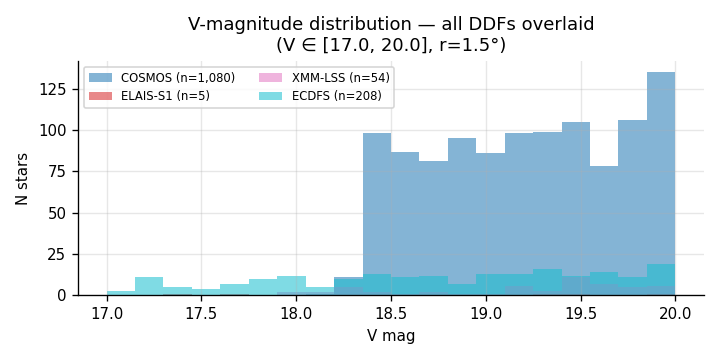

In [10]:
fields_with_data = [(n, df) for n, df in ddf_stars.items() if not df.empty and "V_mag" in df.columns]

if not fields_with_data:
    print("No V_mag data available — skipping magnitude distributions.")
else:
    n_fields = len(fields_with_data)
    colors = cm.tab10(np.linspace(0, 1, n_fields))

    ncols = min(3, n_fields)
    nrows = int(np.ceil(n_fields / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2 * nrows), squeeze=False)
    bin_edges = np.linspace(MAG_MIN, MAG_MAX, 21)  # 20 bins across the selection window

    for idx, (field_name, df) in enumerate(fields_with_data):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        ax.hist(
            df["V_mag"].dropna(),
            bins=bin_edges,
            color=colors[idx],
            edgecolor="white",
            linewidth=0.4,
            alpha=0.85,
        )
        ax.set_xlabel("V mag")
        ax.set_ylabel("N stars")
        ax.set_title(f"{field_name}\n(n={len(df):,})")

    for idx in range(n_fields, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    plt.suptitle(
        f"V-magnitude distribution per DDF\n"
        f"(stable stars, V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)",
        fontsize=11,
        y=1.01,
    )
    plt.tight_layout()
    savefig("vmag_distribution_per_ddf")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 3))
    for (field_name, df), color in zip(fields_with_data, colors):
        ax.hist(
            df["V_mag"].dropna(),
            bins=bin_edges,
            color=color,
            alpha=0.55,
            edgecolor="none",
            label=f"{field_name} (n={len(df):,})",
        )
    ax.set_xlabel("V mag")
    ax.set_ylabel("N stars")
    ax.set_title(
        f"V-magnitude distribution — all DDFs overlaid\n(V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)"
    )
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    savefig("vmag_distribution_all_ddfs")
    plt.show()

## 8. Spectral-type distribution per DDF

We use the leading character of the Simbad `spectral_type` column to get a
coarse MK classification (O, B, A, F, G, K, M).  
The distribution provides a sanity check: at V ≈ 17–20 one expects mostly
dwarf stars of solar-type (G, K) or cooler (M), with few hot stars.


Spectral-type counts per DDF (leading MK class):
          O  B  A  F  G  K  M     ?
COSMOS    0  0  1  4  0  2  8  1065
ELAIS-S1  0  0  0  0  0  0  0     5
XMM-LSS   0  0  0  0  0  0  0    54
ECDFS     0  0  0  0  0  0  2   206
  -> saved spectral_type_per_ddf.{pdf,png}


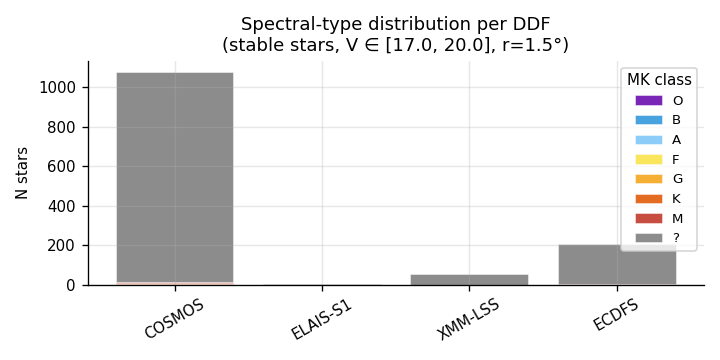

  -> saved spectral_type_per_ddf_known_only.{pdf,png}


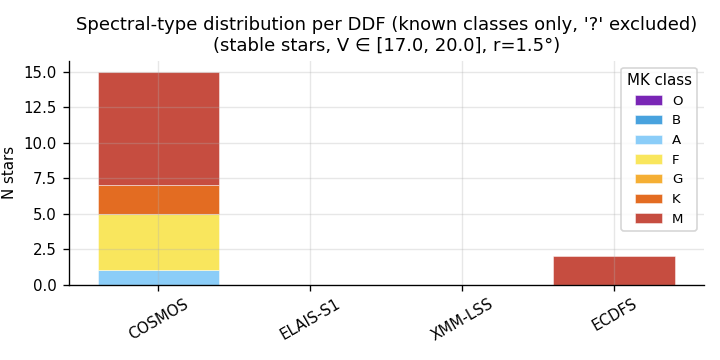

In [11]:
MK_CLASSES = list("OBAFGKM")  # ordered from hot to cool
MK_COLORS = {
    "O": "#6a0dad",
    "B": "#3498db",
    "A": "#7fc8f8",
    "F": "#f9e44b",
    "G": "#f4a61e",
    "K": "#e05c0a",
    "M": "#c0392b",
    "?": "grey",
}


def leading_mk(sp_type_val) -> str:
    """
    Extract the leading MK letter from a Simbad spectral-type string.
    Returns '?' for unknown or missing values.
    """
    val = str(sp_type_val).strip()
    if not val or val in ("nan", "--", "None"):
        return "?"
    first = val[0].upper()
    return first if first in MK_CLASSES else "?"


fields_with_sptype = [
    (n, df) for n, df in ddf_stars.items() if not df.empty and "spectral_type" in df.columns
]

if not fields_with_sptype:
    print("No spectral-type data — skipping.")
else:
    sp_counts = {}
    for field_name, df in fields_with_sptype:
        mk_series = df["spectral_type"].apply(leading_mk)
        counts = {mk: int((mk_series == mk).sum()) for mk in MK_CLASSES + ["?"]}
        sp_counts[field_name] = counts

    df_sp = pd.DataFrame(sp_counts, index=MK_CLASSES + ["?"]).T
    print("Spectral-type counts per DDF (leading MK class):")
    print(df_sp.to_string())

    fig, ax = plt.subplots(figsize=(6, 3))
    bottom = np.zeros(len(df_sp))
    x = np.arange(len(df_sp))
    for mk in MK_CLASSES + ["?"]:
        vals = df_sp[mk].values.astype(float)
        ax.bar(
            x,
            vals,
            bottom=bottom,
            color=MK_COLORS.get(mk, "grey"),
            edgecolor="white",
            linewidth=0.3,
            label=mk,
            alpha=0.9,
        )
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(df_sp.index.tolist(), rotation=30)
    ax.set_ylabel("N stars")
    ax.set_title(
        f"Spectral-type distribution per DDF\n"
        f"(stable stars, V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)"
    )
    ax.legend(title="MK class", fontsize=8, loc="upper right")
    plt.tight_layout()
    savefig("spectral_type_per_ddf")
    plt.show()

    # ── Zoomed-in version excluding the 'unknown' bucket ─────────────────
    # When '?' (unparsed / missing spectral type) dominates the counts, it can
    # visually swamp the stacked bars for O,B,A,F,G,K,M and make them hard to
    # read. This second panel re-plots the same stack without the '?' class so
    # the relative balance between real spectral classes is clearly visible.
    mk_only = MK_CLASSES  # excludes '?'
    df_sp_known = df_sp[mk_only]

    if df_sp_known.to_numpy().sum() == 0:
        print("No stars with a recognised MK class — skipping zoomed-in panel.")
    else:
        fig, ax = plt.subplots(figsize=(6, 3))
        bottom = np.zeros(len(df_sp_known))
        x = np.arange(len(df_sp_known))
        for mk in mk_only:
            vals = df_sp_known[mk].values.astype(float)
            ax.bar(
                x,
                vals,
                bottom=bottom,
                color=MK_COLORS.get(mk, "grey"),
                edgecolor="white",
                linewidth=0.3,
                label=mk,
                alpha=0.9,
            )
            bottom += vals
        ax.set_xticks(x)
        ax.set_xticklabels(df_sp_known.index.tolist(), rotation=30)
        ax.set_ylabel("N stars")
        ax.set_title(
            f"Spectral-type distribution per DDF (known classes only, '?' excluded)\n"
            f"(stable stars, V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)"
        )
        ax.legend(title="MK class", fontsize=8, loc="upper right")
        plt.tight_layout()
        savefig("spectral_type_per_ddf_known_only")
        plt.show()

## 8b. Detailed spectral classification (MK class + numeric subtype + luminosity class)

Simbad spectral types follow the Morgan-Keenan-Kellman (MKK) notation, e.g.
`M5V`, `K2III`, `G8.5IV-V`, `B1Ia`, `sdM3`, `DA2` (white dwarf), `C5,4` (carbon star).
We parse the raw `spectral_type` string into three components:

| Component    | Meaning                                                     | Examples                                    |
|--------------|---------------------------------------------------------------|------------------------------------------------|
| `mk_class`   | Leading temperature class                                      | O, B, A, F, G, K, M, C, S, D (white dwarf), W (Wolf-Rayet) |
| `mk_subtype` | Numeric subtype within the class (0=hottest, 9=coolest)        | `M5` → 5.0, `G8.5` → 8.5                      |
| `lum_class`  | Luminosity class (roman numerals)                               | I/Ia/Ib (supergiant), II (bright giant), III (giant), IV (subgiant), V (dwarf/main sequence), VI or 'sd' (subdwarf) |

This finer breakdown is useful to select **main-sequence dwarfs (luminosity class V)**,
which are photometrically the most stable and the best calibration targets,
as opposed to giants/supergiants which can show larger intrinsic variability.


In [12]:
import re

# Regex capturing: optional subdwarf prefix, leading MK letter(s), optional numeric
# subtype, optional luminosity class.
# Examples matched: 'M5V', 'K2III', 'G8.5IV-V', 'B1Ia', 'A0', 'sdM3', 'DA2', 'C5,4J'
SPTYPE_RE = re.compile(
    r"^(?P<sd>sd)?"  # optional subdwarf prefix
    r"(?P<mk>[OBAFGKMCSWD]{1,2})"  # MK class letter(s) (incl. white dwarf D, Wolf-Rayet W)
    r"(?P<sub>\d+\.?\d*)?"  # numeric subtype, possibly with decimal
    r"(?P<lum>I{1,3}a?b?|IV|VI?)?",  # luminosity class (roman numerals)
    re.IGNORECASE,
)

LUM_LABELS = {
    "I": "I/Ia/Ib (supergiant)",
    "IA": "I/Ia/Ib (supergiant)",
    "IB": "I/Ia/Ib (supergiant)",
    "II": "II (bright giant)",
    "III": "III (giant)",
    "IV": "IV (subgiant)",
    "V": "V (dwarf / main sequence)",
    "VI": "VI (subdwarf)",
    "": "unknown",
}


def parse_spectral_type(sp_type_val) -> tuple[str, float, str]:
    """
    Parse a raw Simbad spectral-type string into (mk_class, mk_subtype, lum_class).

    Returns ('?', np.nan, 'unknown') when the string cannot be parsed
    (missing value, peculiar notation, composite/binary spectral types, etc.).
    A leading 'sd' (subdwarf) prefix overrides the luminosity class to 'VI (subdwarf)'.
    """
    val = str(sp_type_val).strip()
    if not val or val in ("nan", "--", "None"):
        return "?", np.nan, "unknown"

    m = SPTYPE_RE.match(val)
    if not m:
        return "?", np.nan, "unknown"

    mk = m.group("mk").upper()
    if mk not in MK_CLASSES and mk not in ("C", "S", "W", "D"):
        return "?", np.nan, "unknown"

    sub = float(m.group("sub")) if m.group("sub") else np.nan

    if m.group("sd"):
        lum_label = "VI (subdwarf)"
    else:
        lum_raw = (m.group("lum") or "").upper()
        lum_label = LUM_LABELS.get(lum_raw, "unknown")

    return mk, sub, lum_label


print("parse_spectral_type() defined.")
print(parse_spectral_type("M5V"))
print(parse_spectral_type("K2III"))
print(parse_spectral_type("G8.5IV-V"))
print(parse_spectral_type("sdM3"))
print(parse_spectral_type("--"))

parse_spectral_type() defined.
('M', 5.0, 'V (dwarf / main sequence)')
('K', 2.0, 'III (giant)')
('G', 8.5, 'I/Ia/Ib (supergiant)')
('M', 3.0, 'VI (subdwarf)')
('?', nan, 'unknown')


In [13]:
# Apply the parser to every DDF DataFrame and add 3 new columns:
#   mk_class, mk_subtype, lum_class
for field_name, df in ddf_stars.items():
    if df.empty or "spectral_type" not in df.columns:
        continue
    parsed = df["spectral_type"].apply(parse_spectral_type)
    df["mk_class"] = parsed.apply(lambda t: t[0])
    df["mk_subtype"] = parsed.apply(lambda t: t[1])
    df["lum_class"] = parsed.apply(lambda t: t[2])

print("Detailed spectral classification added: mk_class, mk_subtype, lum_class")

# Quick look at COSMOS, if present
if "COSMOS" in ddf_stars and not ddf_stars["COSMOS"].empty:
    display(
        ddf_stars["COSMOS"][["simbad_id", "spectral_type", "mk_class", "mk_subtype", "lum_class"]].head(15)
    )

Detailed spectral classification added: mk_class, mk_subtype, lum_class


,simbad_id,spectral_type,mk_class,mk_subtype,lum_class
0,COSMOS J100237.53+013431.0,NaN,?,NaN,unknown
1,COSMOS 178054,NaN,?,NaN,unknown
2,COSMOS 1014787,NaN,?,NaN,unknown
3,2MASS J10025238+0250419,NaN,?,NaN,unknown
4,COSMOS 1944821,NaN,?,NaN,unknown
5,2MASS J09595809+0239270,NaN,?,NaN,unknown
6,2MASS J09581929+0237139,NaN,?,NaN,unknown
7,COSMOS 3208465,NaN,?,NaN,unknown
8,2MASS J09583056+0147456,NaN,?,NaN,unknown
9,2MASS J10030931+0132249,NaN,?,NaN,unknown


Luminosity-class counts per DDF:
lum_class  I/Ia/Ib (supergiant)  II (bright giant)  III (giant)  IV (subgiant)  V (dwarf / main sequence)  VI (subdwarf)  unknown
COSMOS                        0                  0            1              0                          1              0     1078
ELAIS-S1                      0                  0            0              0                          0              0        5
XMM-LSS                       0                  0            0              0                          0              1       53
ECDFS                         0                  0            0              0                          0              0      208
  -> saved luminosity_class_per_ddf.{pdf,png}


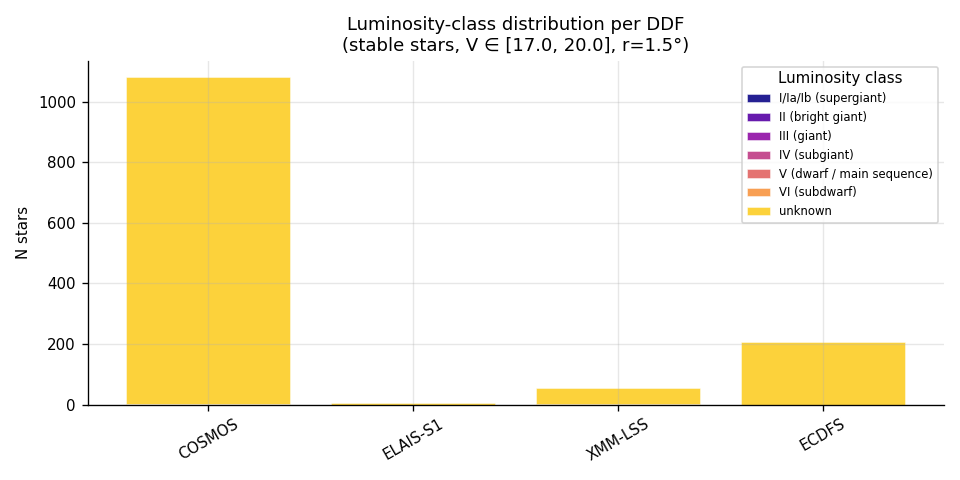

  -> saved luminosity_class_per_ddf_known_only.{pdf,png}


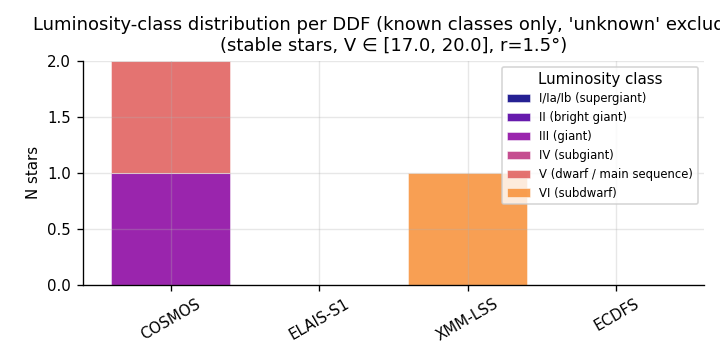

In [14]:
# ── Luminosity-class breakdown per DDF ────────────────────────────────────────────
fields_with_lum = [(n, df) for n, df in ddf_stars.items() if not df.empty and "lum_class" in df.columns]

if not fields_with_lum:
    print("No luminosity-class data — skipping.")
else:
    lum_order = [
        "I/Ia/Ib (supergiant)",
        "II (bright giant)",
        "III (giant)",
        "IV (subgiant)",
        "V (dwarf / main sequence)",
        "VI (subdwarf)",
        "unknown",
    ]
    lum_colors = dict(zip(lum_order, cm.plasma(np.linspace(0, 0.9, len(lum_order)))))

    lum_counts = {}
    for field_name, df in fields_with_lum:
        counts = df["lum_class"].value_counts().reindex(lum_order, fill_value=0)
        lum_counts[field_name] = counts

    df_lum = pd.DataFrame(lum_counts).T
    print("Luminosity-class counts per DDF:")
    print(df_lum.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    bottom = np.zeros(len(df_lum))
    x = np.arange(len(df_lum))
    for lum in lum_order:
        vals = df_lum[lum].values.astype(float)
        ax.bar(
            x,
            vals,
            bottom=bottom,
            color=lum_colors[lum],
            edgecolor="white",
            linewidth=0.3,
            label=lum,
            alpha=0.9,
        )
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(df_lum.index.tolist(), rotation=30)
    ax.set_ylabel("N stars")
    ax.set_title(
        f"Luminosity-class distribution per DDF\n"
        f"(stable stars, V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)"
    )
    ax.legend(title="Luminosity class", fontsize=7, loc="upper right")
    plt.tight_layout()
    savefig("luminosity_class_per_ddf")
    plt.show()

    # ── Zoomed-in version excluding the 'unknown' bucket ─────────────────
    lum_known = [l for l in lum_order if l != "unknown"]
    df_lum_known = df_lum[lum_known]

    if df_lum_known.to_numpy().sum() == 0:
        print("No stars with a recognised luminosity class — skipping zoomed-in panel.")
    else:
        fig, ax = plt.subplots(figsize=(6, 3))
        bottom = np.zeros(len(df_lum_known))
        x = np.arange(len(df_lum_known))
        for lum in lum_known:
            vals = df_lum_known[lum].values.astype(float)
            ax.bar(
                x,
                vals,
                bottom=bottom,
                color=lum_colors[lum],
                edgecolor="white",
                linewidth=0.3,
                label=lum,
                alpha=0.9,
            )
            bottom += vals
        ax.set_xticks(x)
        ax.set_xticklabels(df_lum_known.index.tolist(), rotation=30)
        ax.set_ylabel("N stars")
        ax.set_title(
            f"Luminosity-class distribution per DDF (known classes only, 'unknown' excluded)\n"
            f"(stable stars, V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)"
        )
        ax.legend(title="Luminosity class", fontsize=7, loc="upper right")
        plt.tight_layout()
        savefig("luminosity_class_per_ddf_known_only")
        plt.show()

  -> saved mk_subtype_distribution_all_ddfs.{pdf,png}


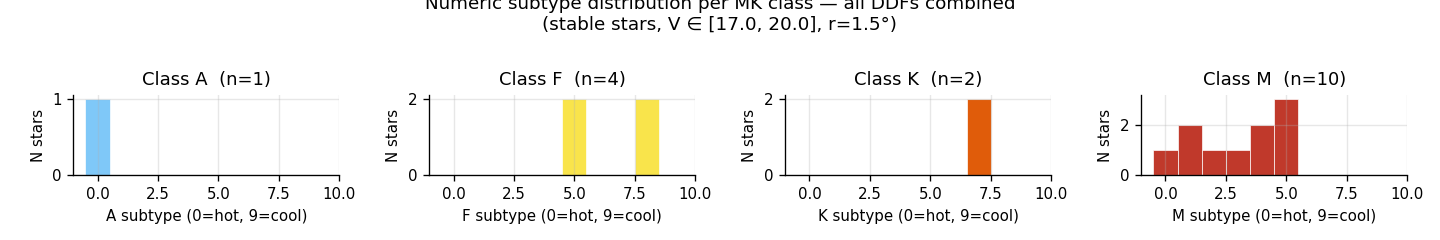

In [15]:
# ── Numeric subtype distribution within each MK class (all DDFs combined) ─────
frames_all = [df for df in ddf_stars.values() if not df.empty and "mk_subtype" in df.columns]

if not frames_all:
    print("No mk_subtype data — skipping.")
else:
    df_all = pd.concat(frames_all, ignore_index=True)
    classes_present = [c for c in MK_CLASSES if (df_all["mk_class"] == c).any()]

    if not classes_present:
        print("No recognised MK classes with numeric subtype — skipping.")
    else:
        ncols = min(4, len(classes_present))
        nrows = int(np.ceil(len(classes_present) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2 * nrows), squeeze=False)

        for idx, mk in enumerate(classes_present):
            row, col = divmod(idx, ncols)
            ax = axes[row][col]
            sub_vals = df_all.loc[df_all["mk_class"] == mk, "mk_subtype"].dropna()
            if sub_vals.empty:
                ax.text(0.5, 0.5, "no subtype", ha="center", va="center", transform=ax.transAxes)
            else:
                ax.hist(
                    sub_vals,
                    bins=np.arange(-0.5, 10.5, 1),
                    color=MK_COLORS.get(mk, "grey"),
                    edgecolor="white",
                    linewidth=0.4,
                )
            ax.set_xlabel(f"{mk} subtype (0=hot, 9=cool)")
            ax.set_ylabel("N stars")
            ax.set_title(f"Class {mk}  (n={len(sub_vals):,})")

        for idx in range(len(classes_present), nrows * ncols):
            row, col = divmod(idx, ncols)
            axes[row][col].set_visible(False)

        plt.suptitle(
            f"Numeric subtype distribution per MK class — all DDFs combined\n"
            f"(stable stars, V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)",
            fontsize=11,
            y=1.02,
        )
        plt.tight_layout()
        savefig("mk_subtype_distribution_all_ddfs")
        plt.show()

## 9. Parallax distribution (Milky Way / extragalactic contamination check)

Stars with a measured Simbad parallax > 1 mas are likely Milky Way foreground
stars.  Objects with parallax ≤ 0 or unmeasured are at cosmological distance
(or have uncertain astrometry).  
This plot helps assess the foreground-star fraction in each DDF.


  -> saved parallax_distribution_per_ddf.{pdf,png}


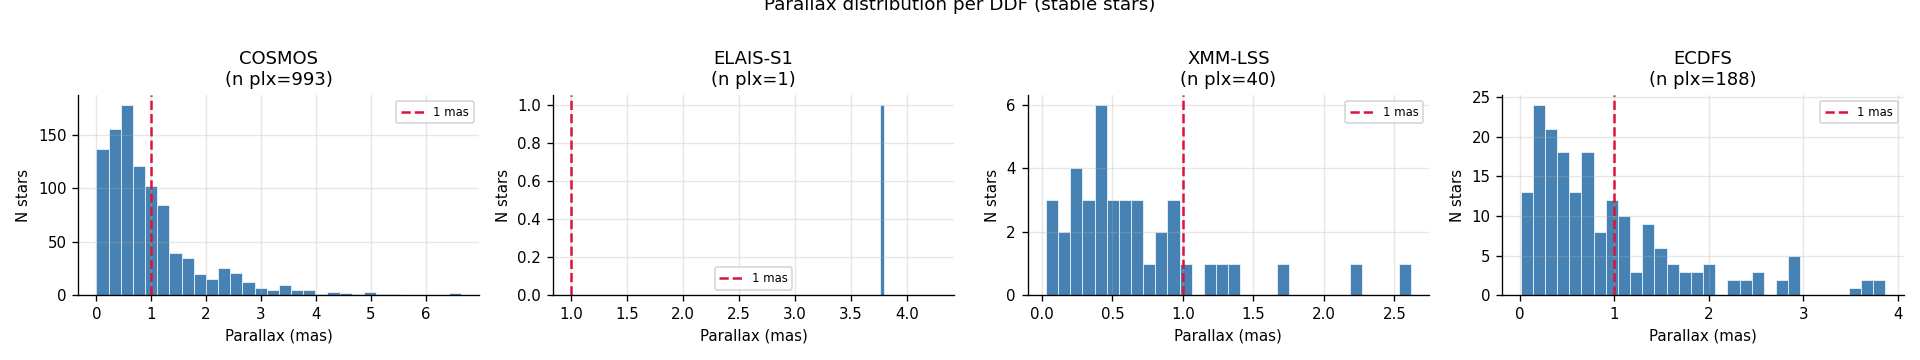

In [16]:
fields_with_plx = [(n, df) for n, df in ddf_stars.items() if not df.empty and "parallax_mas" in df.columns]

if not fields_with_plx:
    print("No parallax data — skipping.")
else:
    fig, axes = plt.subplots(1, len(fields_with_plx), figsize=(4 * len(fields_with_plx), 3), squeeze=False)
    for ax, (field_name, df) in zip(axes[0], fields_with_plx):
        plx = df["parallax_mas"].dropna()
        if plx.empty:
            ax.text(0.5, 0.5, "no parallax", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.hist(
                plx.clip(lower=-5, upper=50), bins=30, color="steelblue", edgecolor="white", linewidth=0.4
            )
            ax.axvline(1.0, color="crimson", lw=1.5, ls="--", label="1 mas")
            ax.legend(fontsize=7)
        ax.set_xlabel("Parallax (mas)")
        ax.set_ylabel("N stars")
        ax.set_title(f"{field_name}\n(n plx={len(plx):,})")

    plt.suptitle("Parallax distribution per DDF (stable stars)", fontsize=11, y=1.01)
    plt.tight_layout()
    savefig("parallax_distribution_per_ddf")
    plt.show()

## 10. Build and save the master catalogue

Concatenate all DDF catalogues into a single master table and save it as
both CSV and Parquet for downstream use with Rubin Butler.

Columns retained for Butler cross-matching:
- `simbad_id`    — Simbad main identifier
- `ra_deg`       — Right Ascension (deg, ICRS)
- `dec_deg`      — Declination (deg, ICRS)
- `V_mag`        — V-band magnitude
- `B_mag`        — B-band magnitude
- `R_mag`        — R-band magnitude
- `simbad_otype` — Simbad object type
- `spectral_type`— Raw MK spectral type string
- `mk_class`     — Parsed MK temperature class (O,B,A,F,G,K,M,...)
- `mk_subtype`   — Parsed numeric subtype (0=hottest, 9=coolest)
- `lum_class`    — Parsed luminosity class (supergiant/giant/subgiant/dwarf/subdwarf)
- `parallax_mas` — Parallax (mas)
- `pmra_mas_yr`  — Proper motion in RA × cos(Dec) (mas/yr)
- `pmdec_mas_yr` — Proper motion in Dec (mas/yr)
- `stable`       — True when no Simbad variability flag
- `field`        — DDF field name


In [17]:
frames = [df for df in ddf_stars.values() if not df.empty]

if not frames:
    print("No data to concatenate — master catalogue is empty.")
    df_master = pd.DataFrame()
else:
    df_master = pd.concat(frames, ignore_index=True)

    keep_cols = [
        "simbad_id",
        "ra_deg",
        "dec_deg",
        "V_mag",
        "B_mag",
        "R_mag",
        "I_mag",
        "simbad_otype",
        "spectral_type",
        "mk_class",
        "mk_subtype",
        "lum_class",
        "parallax_mas",
        "pmra_mas_yr",
        "pmdec_mas_yr",
        "stable",
        "field",
    ]
    keep_cols = [c for c in keep_cols if c in df_master.columns]
    df_master = df_master[keep_cols].copy()

    sort_cols = [c for c in ["field", "V_mag"] if c in df_master.columns]
    df_master.sort_values(sort_cols, inplace=True)
    df_master.reset_index(drop=True, inplace=True)

    print(f"Master catalogue: {len(df_master):,} stable stars across {df_master['field'].nunique()} DDFs")
    print(f"Columns: {list(df_master.columns)}")
    display(df_master.head(10))

    tag = f"V{MAG_MIN:.0f}-{MAG_MAX:.0f}_r{SEARCH_RADIUS_DEG:.1f}deg"
    csv_out = os.path.join(DIR_DATA, f"master_stable_stars_{tag}.csv")
    parquet_out = os.path.join(DIR_DATA, f"master_stable_stars_{tag}.parquet")
    df_master.to_csv(csv_out, index=False)
    df_master.to_parquet(parquet_out, index=False)
    print(f"\nSaved:\n  CSV     → {csv_out}\n  Parquet → {parquet_out}")

Master catalogue: 1,347 stable stars across 4 DDFs
Columns: ['simbad_id', 'ra_deg', 'dec_deg', 'V_mag', 'B_mag', 'R_mag', 'I_mag', 'simbad_otype', 'spectral_type', 'mk_class', 'mk_subtype', 'lum_class', 'parallax_mas', 'pmra_mas_yr', 'pmdec_mas_yr', 'stable', 'field']


,simbad_id,ra_deg,dec_deg,V_mag,B_mag,R_mag,I_mag,simbad_otype,spectral_type,mk_class,mk_subtype,lum_class,parallax_mas,pmra_mas_yr,pmdec_mas_yr,stable,field
0,2MASS J10010465+0227361,150.269422,2.460136,18.160999,18.471001,NaN,17.77,*,NaN,?,NaN,unknown,0.4111,-12.513,0.120,True,COSMOS
1,COSMOS 818920,150.394436,1.889753,18.284000,18.403999,NaN,18.17,*,NaN,?,NaN,unknown,0.3684,-1.894,-3.533,True,COSMOS
2,2MASS J09574311+0217297,149.429657,2.291566,18.294001,19.148001,NaN,NaN,*,NaN,?,NaN,unknown,0.9310,-6.644,6.332,True,COSMOS
3,2MASS J10000154+0215563,150.006447,2.265676,18.296000,18.759001,NaN,NaN,*,NaN,?,NaN,unknown,0.3591,-11.900,1.836,True,COSMOS
4,2MASS J10013353+0223542,150.389727,2.398485,18.308001,19.243000,NaN,NaN,*,NaN,?,NaN,unknown,1.0739,-10.493,0.625,True,COSMOS
5,2MASS J09594478+0148011,149.936636,1.800303,18.312000,19.128000,NaN,NaN,*,NaN,?,NaN,unknown,1.0874,-14.461,-3.860,True,COSMOS
6,2MASS J10010851+0214597,150.285611,2.249923,18.320000,18.978001,NaN,NaN,*,NaN,?,NaN,unknown,0.5145,-7.307,-0.838,True,COSMOS
7,2MASS J09575881+0153235,149.495064,1.889885,18.322001,19.243000,NaN,NaN,*,NaN,?,NaN,unknown,1.1714,-1.129,-10.866,True,COSMOS
8,2MASS J10001512+0213282,150.063007,2.224490,18.332001,18.988001,NaN,NaN,*,NaN,?,NaN,unknown,0.7583,-11.913,-8.210,True,COSMOS
9,2MASS J09584090+0139332,149.670287,1.659464,18.337000,18.669001,NaN,NaN,*,NaN,?,NaN,unknown,0.4432,-10.420,-4.044,True,COSMOS



Saved:
  CSV     → data_SIMBAD_01/master_stable_stars_V17-20_r1.5deg.csv
  Parquet → data_SIMBAD_01/master_stable_stars_V17-20_r1.5deg.parquet


## 11. Summary bar chart — star counts per DDF

  -> saved nstars_per_ddf.{pdf,png}


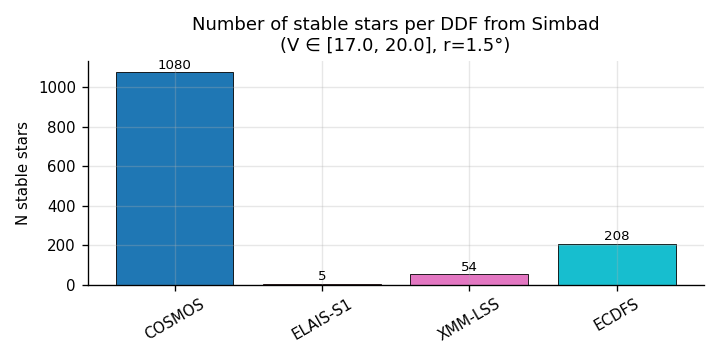

In [18]:
if df_summary["n_stars"].sum() == 0:
    print("No stars found — skipping summary chart.")
else:
    fields = df_summary.index.tolist()
    n_stars = df_summary["n_stars"].values
    colors = cm.tab10(np.linspace(0, 1, len(fields)))

    fig, ax = plt.subplots(figsize=(6, 3))
    bars = ax.bar(fields, n_stars, color=colors, edgecolor="k", linewidth=0.5)
    for bar, n in zip(bars, n_stars):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(int(n)),
            ha="center",
            va="bottom",
            fontsize=8,
        )
    ax.set_ylabel("N stable stars")
    ax.set_title(
        f"Number of stable stars per DDF from Simbad\n(V ∈ [{MAG_MIN}, {MAG_MAX}], r={SEARCH_RADIUS_DEG}°)"
    )
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    savefig("nstars_per_ddf")
    plt.show()

## 12. Next steps

1. **`02_crossmatch_rubin_simbad.ipynb`** — Cross-match this Simbad stable-star
   catalogue with Rubin DP2 `diaObject` or `object` tables using a spatial
   matching radius (e.g. 0.5 arcsec) to identify which stars have Rubin detections.

2. **`03_lightcurves_stable_stars.ipynb`** — Fetch Rubin light curves for the
   matched stars and verify photometric stability (RMS scatter, reduced χ² against
   a constant).

3. **`04_colour_colour_diagram.ipynb`** — Build B−V vs V−R colour-colour diagrams
   using the Simbad photometry and compare with Rubin synthetic photometry
   (PSF fluxes in ugrizy).

4. **`05_simbad_rubin_zeropoint.ipynb`** — Use the stable Simbad stars as flux
   standards to estimate per-visit photometric zero-points and identify
   outlier exposures.
